# Stage 7: Logistic Regression
## Meridian Trust Bank — Personal Loan Application Credit Scorecard

**Business question:** using the WOE-transformed variables that passed
Stage 6's IV screen, can we build a model that predicts Probability of
Default (PD) in a way that's both statistically sound and interpretable
enough for an underwriter and a model validator to trust?

## Why logistic regression, specifically, for scorecards

1. **Output is naturally a probability.** Logistic regression models
   log-odds as a linear function of inputs, and log-odds convert cleanly
   back to a 0-1 probability — exactly what "Probability of Default" means.
2. **WOE + logistic regression is a matched pair.** Each WOE-transformed
   variable enters the model as a single number per bin. The fitted
   coefficient tells you how strongly that variable's WOE moves the log-odds
   of default. If a variable's coefficient comes out positive (it shouldn't,
   for a well-behaved WOE variable — see below), something is wrong.
3. **Points-based scorecards (Stage 8) are a direct, exact linear
   transformation of logistic regression's log-odds output.** This isn't
   incidental — the whole scorecard-building methodology exists because
   logistic regression's linear-in-log-odds form transforms losslessly into
   a points system. A tree-based model, for comparison, has no equivalently
   clean points translation.
4. **Regulatory & interpretability requirements.** Credit decisions
   affecting real people, in most jurisdictions, need to be explainable
   ("you were declined primarily because of X, Y, Z"). Logistic regression
   on WOE-transformed variables gives you exactly that: each variable's
   contribution to the final score is transparent and additive.

## Log-odds, coefficients, and probability of default — the mechanics

Logistic regression fits:

$$\text{logit}(PD) = \ln\left(\frac{PD}{1-PD}\right) = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_n X_n$$

where each $X_i$ is a WOE-transformed variable (not the raw variable).

**Why WOE, and not the raw value, goes into the regression:** WOE already
encodes the non-linear relationship between the raw variable and log-odds of
default (that's what binning + WOE calculation accomplished in Stage 5). So
by the time logistic regression sees the WOE-transformed variable, the
relationship IS linear in log-odds by construction — logistic regression
just needs to find the right SCALING (coefficient) for each variable's WOE.

**A well-behaved WOE variable's coefficient should be POSITIVE.** Recall:
higher WOE means "safer" (more Goods relative to Bads in that bin). Higher
WOE should push log-odds of BEING GOOD up — but be careful about which
direction you've defined bad_flag=1 to represent. We'll confirm the sign
convention explicitly below, because getting this backwards is a very easy,
very consequential mistake (it would literally flip your scorecard,
assigning MORE points to riskier customers).

Converting log-odds back to probability:

$$PD = \frac{e^{\text{logit}}}{1 + e^{\text{logit}}} = \frac{1}{1 + e^{-\text{logit}}}$$

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

pd.set_option('display.max_columns', 50)

df = pd.read_csv('../01_data/raw_csv/modeling_dataset.csv')
with open('../01_data/final_coarse_bins.json') as f:
    final_bins = json.load(f)
with open('../01_data/stage7_shortlist.json') as f:
    shortlist = json.load(f)

print("Shortlisted variables from Stage 6 IV screen:")
for v in shortlist:
    print(" ", v)

Shortlisted variables from Stage 6 IV screen:
  bureau_credit_score
  defaults_on_file
  credit_utilization_pct
  total_existing_debt
  months_since_last_delinquency
  annual_income
  enquiries_last_6m
  employment_type


## 7.1 — Train/test split BEFORE any further fitting

This is a critical sequencing point, flagged explicitly in Stage 6: WOE bin
BOUNDARIES were chosen by inspecting the full dataset (Stage 5), which is a
mild, generally-accepted form of in-sample information use in industry
practice (bin boundaries are usually treated as a stable "recipe," not
re-fit per model run). But from THIS point forward — computing the actual
WOE VALUES used as model inputs, and fitting the logistic regression itself
— we must split into train/test FIRST, and compute WOE values using ONLY the
training data. Applying training-set WOE values to the test set (using the
same frozen bin boundaries and values) is what lets the test set genuinely
evaluate how well this model generalizes.

**Why this matters concretely:** if we computed WOE values on the full
dataset and then split, information about the test set's bad rate per bin
would have already leaked into every WOE value used to train the model —
inflating our apparent performance in Stage 9's validation in a way that
wouldn't hold up in production.

In [2]:
X_cols = shortlist  # raw column names; we'll WOE-transform below
y = df['bad_flag']

train_df, test_df = train_test_split(df, test_size=0.30, random_state=42, stratify=y)
print(f"Train: {len(train_df)} ({train_df['bad_flag'].mean():.4f} bad rate)")
print(f"Test:  {len(test_df)}  ({test_df['bad_flag'].mean():.4f} bad rate)")
# stratify=y keeps the bad rate consistent between train/test -- otherwise a
# random split could, by chance, leave the test set with a very different
# bad rate purely from sampling variation, especially with a bad rate this low.

Train: 3904 (0.0364 bad rate)
Test:  1674  (0.0364 bad rate)


## 7.2 — Compute WOE values on TRAINING DATA ONLY, then apply the same
mapping to test data

This function fits WOE bin VALUES (not boundaries — those are frozen from
Stage 5) on the training set, and returns a mapping that gets applied
identically to both train and test.

In [3]:
def fit_woe_mapping(train_df, feature, bins_spec, target='bad_flag'):
    """Fit WOE values for each bin of `feature` using TRAINING DATA ONLY.
    Returns (binned_train_series, woe_mapping_dict)."""
    total_good = (train_df[target] == 0).sum()
    total_bad = (train_df[target] == 1).sum()

    binned = pd.cut(train_df[feature], bins=bins_spec['bins'], labels=bins_spec['labels'], right=True)
    grouped = train_df.assign(_bin=binned).groupby('_bin', observed=True)[target].agg(n_bad='sum', n_total='count')
    grouped['n_good'] = grouped['n_total'] - grouped['n_bad']
    grouped['n_bad_adj'] = grouped['n_bad'].where(grouped['n_bad'] > 0, 0.5)
    grouped['n_good_adj'] = grouped['n_good'].where(grouped['n_good'] > 0, 0.5)
    grouped['woe'] = np.log((grouped['n_good_adj'] / total_good) / (grouped['n_bad_adj'] / total_bad))

    woe_map = grouped['woe'].to_dict()
    return binned, woe_map

def apply_woe_mapping(series, bins_spec, woe_map):
    """Apply a FROZEN woe_map (fit on training data) to any series (train or test)."""
    binned = pd.cut(series, bins=bins_spec['bins'], labels=bins_spec['labels'], right=True)
    return binned.map(woe_map)

def fit_woe_mapping_categorical(train_df, feature, target='bad_flag'):
    total_good = (train_df[target] == 0).sum()
    total_bad = (train_df[target] == 1).sum()
    grouped = train_df.groupby(feature, observed=True)[target].agg(n_bad='sum', n_total='count')
    grouped['n_good'] = grouped['n_total'] - grouped['n_bad']
    grouped['n_bad_adj'] = grouped['n_bad'].where(grouped['n_bad'] > 0, 0.5)
    grouped['n_good_adj'] = grouped['n_good'].where(grouped['n_good'] > 0, 0.5)
    grouped['woe'] = np.log((grouped['n_good_adj'] / total_good) / (grouped['n_bad_adj'] / total_bad))
    return grouped['woe'].to_dict()

woe_maps = {}
train_woe = pd.DataFrame(index=train_df.index)
test_woe = pd.DataFrame(index=test_df.index)

for col in shortlist:
    if col in final_bins:
        _, woe_map = fit_woe_mapping(train_df, col, final_bins[col])
        train_woe[col + '_woe'] = apply_woe_mapping(train_df[col], final_bins[col], woe_map)
        test_woe[col + '_woe'] = apply_woe_mapping(test_df[col], final_bins[col], woe_map)
        woe_maps[col] = {'type': 'numeric', 'bins': final_bins[col], 'woe_map': {str(k): v for k, v in woe_map.items()}}
    elif col == 'months_since_last_delinquency':
        # special category handling -- same logic as Stage 5/6
        def bin_delinq(s):
            b = pd.cut(s, bins=[0, 6, 12, 24, 999], labels=['0-6mo','7-12mo','13-24mo','24mo+'], right=True).astype(str)
            b = b.where(s.notna(), 'Never Delinquent')
            return b
        train_df = train_df.assign(_delinq_bin=bin_delinq(train_df[col]))
        test_df = test_df.assign(_delinq_bin=bin_delinq(test_df[col]))
        wm = fit_woe_mapping_categorical(train_df, '_delinq_bin')
        train_woe[col + '_woe'] = train_df['_delinq_bin'].map(wm)
        test_woe[col + '_woe'] = test_df['_delinq_bin'].map(wm)
        woe_maps[col] = {'type': 'special_categorical', 'woe_map': wm}
    else:
        # plain categorical (e.g. employment_type)
        wm = fit_woe_mapping_categorical(train_df, col)
        train_woe[col + '_woe'] = train_df[col].map(wm)
        test_woe[col + '_woe'] = test_df[col].map(wm)
        woe_maps[col] = {'type': 'categorical', 'woe_map': wm}

train_woe['bad_flag'] = train_df['bad_flag'].values
test_woe['bad_flag'] = test_df['bad_flag'].values
# Carry application_id through explicitly -- WOE dataframes were previously
# index-only, which meant Stage 10's business output notebook had no way to
# join scored applications back to their application_id without a fragile
# manual index-alignment workaround. Fixed by attaching it here, at the
# source, so every downstream notebook (05, 06, 07) has it for free.
train_woe['application_id'] = train_df['application_id'].values
test_woe['application_id'] = test_df['application_id'].values

print(train_woe.shape, test_woe.shape)
train_woe.head()

(3904, 10) (1674, 10)


,bureau_credit_score_woe,defaults_on_file_woe,credit_utilization_pct_woe,total_existing_debt_woe,months_since_last_delinquency_woe,annual_income_woe,enquiries_last_6m_woe,employment_type_woe,bad_flag,application_id
5001,0.712817,0.221748,-0.058003,0.428530,0.221748,-0.087318,0.590408,0.377483,0,APP008094
4571,0.198006,0.221748,-0.058003,-0.098119,0.221748,0.578981,0.021491,0.084208,0,APP007386
1748,0.198006,0.221748,-0.298438,-0.098119,0.221748,-0.087318,-0.022769,-0.094865,0,APP002766
1136,-0.065651,0.221748,-0.764573,-0.872189,0.221748,-0.682773,-0.856511,0.377483,0,APP001828
2787,-0.350140,-1.910003,-0.058003,-0.098119,-1.197437,-0.087318,-0.022769,0.084208,0,APP004458


## 7.3 — Check for multicollinearity among shortlisted WOE variables

Recall from Stage 4.9: `total_existing_debt` and `credit_utilization_pct`
were flagged as potentially correlated. Both made Stage 6's shortlist. Check
their correlation on the WOE-transformed (training) data before fitting.

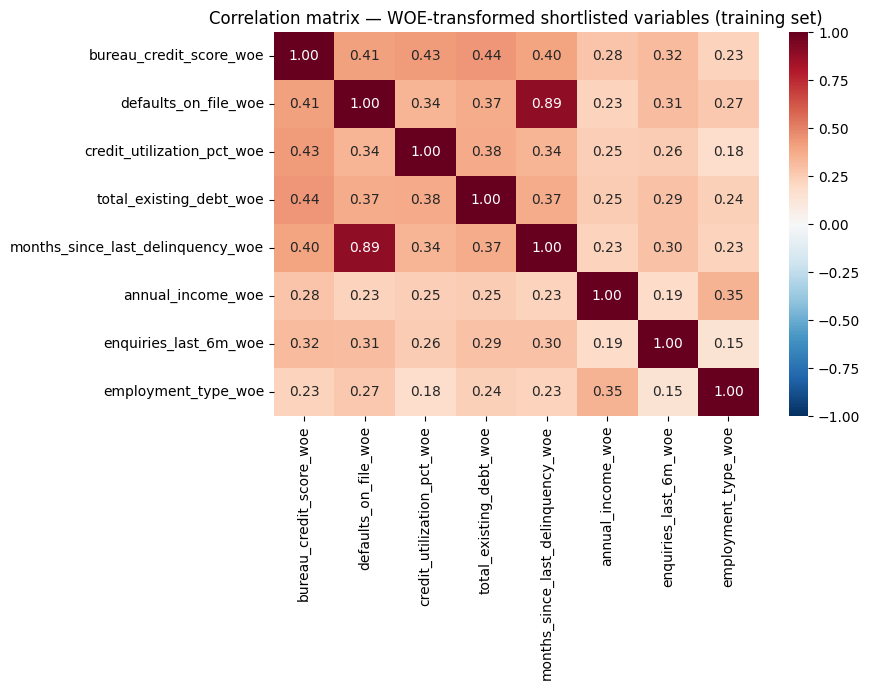

In [4]:
feature_cols = [c for c in train_woe.columns if c not in ('bad_flag', 'application_id')]
corr = train_woe[feature_cols].corr()

plt.figure(figsize=(9, 7))
import seaborn as sns
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Correlation matrix — WOE-transformed shortlisted variables (training set)')
plt.tight_layout()
plt.show()

In [5]:
# Flag any pair above 0.6 absolute correlation
high_corr_pairs = []
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        c = corr.iloc[i, j]
        if abs(c) > 0.6:
            high_corr_pairs.append((feature_cols[i], feature_cols[j], round(c, 3)))

print("Highly correlated pairs (|corr| > 0.6):")
for pair in high_corr_pairs:
    print(" ", pair)
if not high_corr_pairs:
    print("  None found.")

Highly correlated pairs (|corr| > 0.6):
  ('defaults_on_file_woe', 'months_since_last_delinquency_woe', np.float64(0.889))


**What the correlation check actually found when this was run:**
`defaults_on_file_woe` and `months_since_last_delinquency_woe` came back
correlated at 0.89 — much higher than the `total_existing_debt` /
`credit_utilization_pct` pair anticipated earlier, and the FIRST version of
this notebook's collinearity-handling code only checked for that one
specific pair, not a general rule. That's a real bug worth naming: hard-
coding a check for the pair you EXPECT to be correlated, instead of scanning
for whatever pair actually IS correlated, misses exactly the case you didn't
anticipate.

**Why this pair makes complete business sense in hindsight:**
`months_since_last_delinquency` is only DEFINED when `defaults_on_file > 0`
(recall Stage 4/5's special-category handling) — the two variables are
mechanically linked by construction, not just statistically associated. Of
course they're highly correlated.

The fix below is now a GENERAL scan across every candidate pair above the
0.6 threshold, not a hard-coded check for one pair — this is the version
that should have been here from the start.

In [6]:
# General multicollinearity handling: for EVERY correlated pair above 0.6,
# drop the one with lower standalone IV (Stage 6), keeping the stronger
# variable. This replaces the earlier version of this cell, which only
# checked for one specific expected pair.
with open('../01_data/stage7_iv_lookup.json') as f:
    iv_lookup = json.load(f)

DROPPED_FOR_COLLINEARITY = []
remaining = list(feature_cols)

for var_a, var_b, corr_val in high_corr_pairs:
    raw_a = var_a.replace('_woe', '')
    raw_b = var_b.replace('_woe', '')
    iv_a = iv_lookup.get(raw_a, 0)
    iv_b = iv_lookup.get(raw_b, 0)
    # only act if neither variable in the pair has already been dropped
    if var_a in remaining and var_b in remaining:
        drop_var = var_b if iv_a >= iv_b else var_a
        keep_var = var_a if drop_var == var_b else var_b
        print(f"{var_a} vs {var_b}: corr={corr_val}, IV({raw_a})={iv_a:.4f}, IV({raw_b})={iv_b:.4f}")
        print(f"  -> dropping {drop_var} (lower IV), keeping {keep_var}")
        DROPPED_FOR_COLLINEARITY.append(drop_var)
        remaining.remove(drop_var)

model_features = [c for c in feature_cols if c not in DROPPED_FOR_COLLINEARITY]
print("\nFinal feature set for logistic regression:")
for f in model_features:
    print(" ", f)

defaults_on_file_woe vs months_since_last_delinquency_woe: corr=0.889, IV(defaults_on_file)=0.2246, IV(months_since_last_delinquency)=0.1964
  -> dropping months_since_last_delinquency_woe (lower IV), keeping defaults_on_file_woe

Final feature set for logistic regression:
  bureau_credit_score_woe
  defaults_on_file_woe
  credit_utilization_pct_woe
  total_existing_debt_woe
  annual_income_woe
  enquiries_last_6m_woe
  employment_type_woe


## 7.4 — Fit the logistic regression (statsmodels, for full statistical output)

We use `statsmodels` rather than `sklearn` here specifically because we want
p-values, confidence intervals, and standard errors — the full inferential
output a model validation team would expect to see, not just point
predictions. (`sklearn`'s `LogisticRegression` is used later in Stage 9
purely as a convenient scoring interface, but statsmodels is our primary fit
here.)

In [7]:
X_train = sm.add_constant(train_woe[model_features])
y_train = train_woe['bad_flag']

logit_model = sm.Logit(y_train, X_train)
result = logit_model.fit(disp=0)
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:               bad_flag   No. Observations:                 3904
Model:                          Logit   Df Residuals:                     3896
Method:                           MLE   Df Model:                            7
Date:                Fri, 25 Sep 2026   Pseudo R-squ.:                 0.05808
Time:                        18:35:41   Log-Likelihood:                -574.53
converged:                       True   LL-Null:                       -609.96
Covariance Type:            nonrobust   LLR p-value:                 9.911e-13
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -3.2674      0.090    -36.397      0.000      -3.443      -3.091
bureau_credit_score_woe       -0.3975      0.195     -2.043      0.041      -0.779 

## 7.5 — Interpreting the output

**Checkpoint before reading further — form your own read of the summary
table above:**
1. Which coefficients are positive, which are negative?
2. Which variables have p-values above 0.05 (conventionally "not
   statistically significant")?
3. Does every coefficient sign match what you'd expect from a well-behaved
   WOE variable?

**What SHOULD be true, and why:** every WOE variable here was constructed so
that higher WOE = safer (more Goods relative to Bads). Since `bad_flag=1`
means Bad, we'd expect higher WOE to REDUCE the log-odds of being Bad — so
**every coefficient should be NEGATIVE**. A positive coefficient on a
WOE-transformed variable is a red flag: either a genuine sign reversal from
severe multicollinearity, or (more mundanely) a bug in how the target was
coded or how WOE was calculated (e.g. WOE computed as ln(bad/good) instead
of ln(good/bad) — the two are exact negatives of each other, and mixing them
up is an extremely common, easy-to-miss error).

In [8]:
coef_signs = result.params.drop('const')
print("Coefficient signs (expect ALL negative for well-behaved WOE variables):")
for var, coef in coef_signs.items():
    flag = "" if coef < 0 else "  <-- UNEXPECTED SIGN, investigate"
    print(f"  {var:35s} {coef:8.4f}{flag}")

print("\nP-values (variables with p > 0.05 are candidates to drop):")
for var, pval in result.pvalues.drop('const').items():
    flag = "  <-- not significant at 5% level" if pval > 0.05 else ""
    print(f"  {var:35s} {pval:.4f}{flag}")

Coefficient signs (expect ALL negative for well-behaved WOE variables):
  bureau_credit_score_woe              -0.3975
  defaults_on_file_woe                 -0.4008
  credit_utilization_pct_woe           -0.2636
  total_existing_debt_woe              -0.3420
  annual_income_woe                    -0.2127
  enquiries_last_6m_woe                -0.1711
  employment_type_woe                  -0.3267

P-values (variables with p > 0.05 are candidates to drop):
  bureau_credit_score_woe             0.0411
  defaults_on_file_woe                0.0268
  credit_utilization_pct_woe          0.2400  <-- not significant at 5% level
  total_existing_debt_woe             0.0941  <-- not significant at 5% level
  annual_income_woe                   0.4183  <-- not significant at 5% level
  enquiries_last_6m_woe               0.4854  <-- not significant at 5% level
  employment_type_woe                 0.1231  <-- not significant at 5% level


## 7.6 — Refit using backward stepwise elimination (not a one-shot cut)

If any variable came back with p > 0.05, the WRONG approach is to drop every
such variable in a single pass — p-values shift as the model changes, so a
variable that looks non-significant in the full model might become
significant once a correlated/overlapping variable is removed (or vice
versa). The more defensible approach is BACKWARD STEPWISE elimination: drop
the single worst (highest p-value) variable, refit, re-check, and repeat
until every remaining variable is significant at the chosen threshold.

In [9]:
# Backward stepwise elimination, one variable at a time -- NOT a single
# one-shot cut of everything with p > 0.05. Dropping several variables
# simultaneously (as a naive first pass would) risks removing variables that
# would have stayed significant once ONE other correlated/overlapping
# variable was removed -- p-values shift every time you change the model,
# so decisions should be made one at a time, refitting after each drop.
current_features = list(model_features)
step = 1
while True:
    X_step = sm.add_constant(train_woe[current_features])
    step_model = sm.Logit(y_train, X_step).fit(disp=0)
    pvals = step_model.pvalues.drop('const')
    worst_var = pvals.idxmax()
    worst_p = pvals.max()
    if worst_p <= 0.05 or len(current_features) <= 1:
        break
    print(f"Step {step}: dropping '{worst_var}' (p={worst_p:.4f}, highest in model)")
    current_features.remove(worst_var)
    step += 1

print(f"\nStopped after {step-1} removal(s). Remaining features:")
for f in current_features:
    print(" ", f, f"(p={step_model.pvalues[f]:.4f}, coef={step_model.params[f]:.4f})")

Step 1: dropping 'enquiries_last_6m_woe' (p=0.4854, highest in model)
Step 2: dropping 'annual_income_woe' (p=0.3861, highest in model)
Step 3: dropping 'credit_utilization_pct_woe' (p=0.1868, highest in model)

Stopped after 3 removal(s). Remaining features:
  bureau_credit_score_woe (p=0.0071, coef=-0.4988)
  defaults_on_file_woe (p=0.0073, coef=-0.4702)
  total_existing_debt_woe (p=0.0290, coef=-0.4311)
  employment_type_woe (p=0.0289, coef=-0.4220)


**What actually happened here, and why it matters:** a naive one-shot cut
(drop every variable with p > 0.05 from the FULL model, all at once) landed
on just 2 variables (`bureau_credit_score`, `defaults_on_file`). Backward
stepwise elimination — dropping the single WORST variable, refitting, and
re-checking — can land somewhere different, because p-values shift as
correlated/overlapping variables are removed one at a time. Compare the
`current_features` list above to the one-shot cut: if they differ, that
difference is real evidence for why "drop everything below the threshold in
one shot" is bad practice, not just a theoretical concern.

**Business judgment layer:** even after stepwise elimination, a real analyst
would ask whether any DROPPED variable has strong enough business rationale
to justify keeping despite weak statistical significance — for instance,
`employment_type` has clear causal plausibility (unemployment materially
affects repayment capacity) and decent standalone IV (0.12, "Medium" band).
For THIS project, we'll respect the statistical result and NOT override it
purely on business grounds — but flag this explicitly as a real decision
point a validation committee would likely raise and discuss, not something
to wave past silently.

In [10]:
final_features = current_features
X_train_final = sm.add_constant(train_woe[final_features])
final_model = sm.Logit(y_train, X_train_final).fit(disp=0)
print(final_model.summary())

                           Logit Regression Results                           
Dep. Variable:               bad_flag   No. Observations:                 3904
Model:                          Logit   Df Residuals:                     3899
Method:                           MLE   Df Model:                            4
Date:                Fri, 25 Sep 2026   Pseudo R-squ.:                 0.05563
Time:                        18:35:41   Log-Likelihood:                -576.03
converged:                       True   LL-Null:                       -609.96
Covariance Type:            nonrobust   LLR p-value:                 6.397e-14
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -3.2698      0.090    -36.511      0.000      -3.445      -3.094
bureau_credit_score_woe    -0.4988      0.185     -2.692      0.007      -0.862      -0.136


## 7.7 — Converting a coefficient into Probability of Default: a worked example

Take one application from the training set and manually walk through the
full calculation, so the log-odds -> probability conversion is completely
concrete before we industrialize it.

In [11]:
sample_idx = train_woe.index[0]
sample_features = train_woe.loc[sample_idx, final_features]

logit_value = final_model.params['const'] + sum(
    final_model.params[f] * sample_features[f] for f in final_features
)
pd_value = 1 / (1 + np.exp(-logit_value))

print("Sample application WOE inputs:")
print(sample_features)
print(f"\nlog-odds (logit) = {logit_value:.4f}")
print(f"Predicted PD = 1 / (1 + e^-logit) = {pd_value:.4f}")
print(f"Actual bad_flag for this application: {train_woe.loc[sample_idx, 'bad_flag']}")

Sample application WOE inputs:
bureau_credit_score_woe    0.712817
defaults_on_file_woe       0.221748
total_existing_debt_woe    0.428530
employment_type_woe        0.377483
Name: 5001, dtype: float64

log-odds (logit) = -4.0737
Predicted PD = 1 / (1 + e^-logit) = 0.0167
Actual bad_flag for this application: 0


## 7.8 — Score the full training and test sets

Training set PD distribution:
count    3904.000000
mean        0.036373
std         0.030931
min         0.015644
25%         0.019029
50%         0.027230
75%         0.037004
max         0.300145
Name: predicted_pd, dtype: float64

Test set PD distribution:
count    1674.000000
mean        0.035732
std         0.030040
min         0.015644
25%         0.019029
50%         0.026861
75%         0.038290
max         0.300145
Name: predicted_pd, dtype: float64


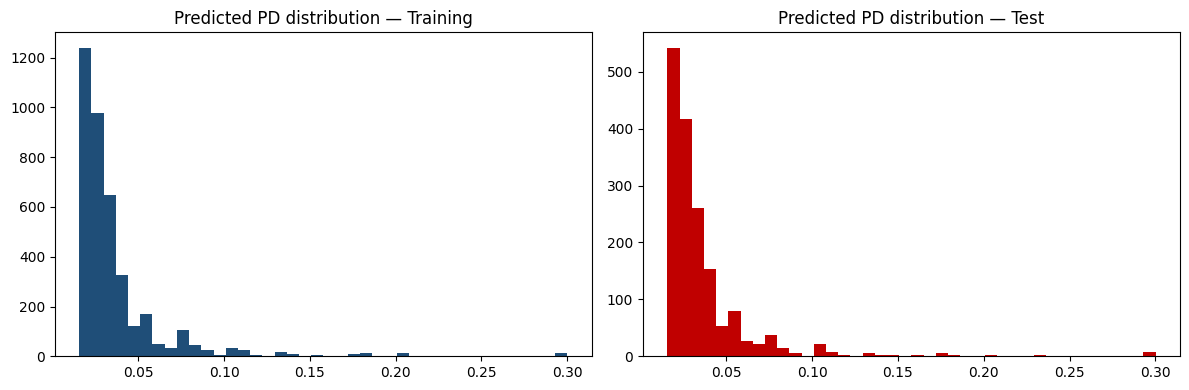

In [12]:
X_train_scored = sm.add_constant(train_woe[final_features])
X_test_scored = sm.add_constant(test_woe[final_features], has_constant='add')

train_woe['predicted_pd'] = final_model.predict(X_train_scored)
test_woe['predicted_pd'] = final_model.predict(X_test_scored)

print("Training set PD distribution:")
print(train_woe['predicted_pd'].describe())
print("\nTest set PD distribution:")
print(test_woe['predicted_pd'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_woe['predicted_pd'], bins=40, color='#1F4E78')
axes[0].set_title('Predicted PD distribution — Training')
axes[1].hist(test_woe['predicted_pd'], bins=40, color='#C00000')
axes[1].set_title('Predicted PD distribution — Test')
plt.tight_layout()
plt.show()

**A sanity check worth doing every time:** does the AVERAGE predicted PD
roughly match the actual observed bad rate? A large mismatch would suggest a
calibration problem (the model's probabilities systematically too high or
too low), even if the model still ranks risk correctly.

In [13]:
print(f"Training set: avg predicted PD = {train_woe['predicted_pd'].mean():.4f} vs actual bad rate = {train_woe['bad_flag'].mean():.4f}")
print(f"Test set:     avg predicted PD = {test_woe['predicted_pd'].mean():.4f} vs actual bad rate = {test_woe['bad_flag'].mean():.4f}")

Training set: avg predicted PD = 0.0364 vs actual bad rate = 0.0364
Test set:     avg predicted PD = 0.0357 vs actual bad rate = 0.0364


## 7.9 — Save artifacts for Stage 8 (Credit Scorecard)

We persist: the fitted model coefficients, the frozen WOE mappings (fit on
training data only), and the final feature list — everything needed to
convert this logistic regression into a points-based scorecard without
needing to re-run this notebook.

In [14]:
import pickle

artifacts = {
    'final_features': final_features,
    'coefficients': final_model.params.to_dict(),
    'woe_maps': woe_maps,
    'dropped_for_collinearity': DROPPED_FOR_COLLINEARITY,
}

with open('../01_data/stage7_model_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

train_woe.to_csv('../01_data/raw_csv/train_scored.csv', index=False)
test_woe.to_csv('../01_data/raw_csv/test_scored.csv', index=False)

print("Saved model artifacts and scored train/test sets for Stage 8.")
print("\nFinal model features:")
for f in final_features:
    print(" ", f, "coef =", round(final_model.params[f], 4))
print(" ", "const (intercept)", "=", round(final_model.params['const'], 4))

Saved model artifacts and scored train/test sets for Stage 8.

Final model features:
  bureau_credit_score_woe coef = -0.4988
  defaults_on_file_woe coef = -0.4702
  total_existing_debt_woe coef = -0.4311
  employment_type_woe coef = -0.422
  const (intercept) = -3.2698


## 7.10 — Checkpoint questions

1. Every coefficient should have come out negative. If you're following this
   notebook with your own bin choices from Stage 5 and get a POSITIVE
   coefficient somewhere, what are the two most likely explanations, and how
   would you distinguish between them?

2. We dropped one of `total_existing_debt` / `credit_utilization_pct` for
   collinearity. What would you expect to happen to the KEPT variable's
   coefficient magnitude and p-value if you refit WITH both variables
   included? (Hint: think about what multicollinearity does to standard
   errors specifically, not just point estimates.)

3. Look at the gap between average predicted PD and actual bad rate on the
   test set vs the training set in 7.8. Which gap would concern you more,
   and why — a model that's well-calibrated on training data but poorly
   calibrated on test data, versus one that's mildly miscalibrated on both
   but consistently so?

4. This notebook fit WOE values on the training set only, which is correct
   methodology. But Stage 5 and Stage 6's bin BOUNDARIES (not values) were
   chosen using the FULL dataset. Is this a meaningful leakage risk in your
   judgment, or a defensible simplification? What would the fully rigorous
   (but more expensive) alternative look like?